In [ ]:
# @title 1. Mount Google Drive and Set Up File Paths
from google.colab import drive
import os
from pathlib import Path

# Mount your Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


In [ ]:
# @title 2. File Paths Set Up

EMPIAR_ID = 10017 # @param{type : 'string'}

DATA_DIR_PATH = '/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/data'     # @param {type: "string"}
DATA_DIR_PATH = DATA_DIR_PATH + f'/EMPIAR-{EMPIAR_ID}/micrographs'
DATA_DIR = Path(DATA_DIR_PATH)

OUTPUT_DIR_PATH ='/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/data'  # @param {type: "string"}
OUTPUT_DIR_PATH = OUTPUT_DIR_PATH + f'/EMPIAR-{OUTPUT_DIR_PATH}/C-CSN-D_micrographs'
OUTPUT_DIR = Path(OUTPUT_DIR_PATH)

TEMP_DIR_PATH = '/content/temp_denoise'                           # @param {type: "string"}
TEMP_DIR = Path(TEMP_DIR_PATH)


!mkdir {OUTPUT_DIR_PATH} -p
!mkdir {TEMP_DIR_PATH} -p


print(f"\nOriginal Data Directory: {DATA_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Temporary Directory: {TEMP_DIR}")

# Create output and temporary directories if they don't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TEMP_DIR.mkdir(parents=True, exist_ok=True)


Original Data Directory: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/micrographs
Output Directory: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/conv-SN_denoised_micrographs
Temporary Directory: /content/temp_denoise


In [ ]:
# @title 3-0. install mrcfile package
!pip install mrcfile -qq

In [ ]:
# @title 3. Import Packages
import subprocess
import shutil
import time
from dataclasses import dataclass, field
import sys

import numpy as np
import mrcfile
import cv2
from numpy.fft import fft2, ifft2
from scipy.signal.windows import gaussian

In [ ]:
# @title 4. Load in Denoise Process Function Copy From CryoSegNet

# Code for implementing different different image processing techniques for denoising.

def transform(image):
    i_min = image.min()
    i_max = image.max()

    image = ((image - i_min)/(i_max - i_min)) * 255
    return image.astype(np.uint8)


def standard_scaler(image):
    image = image.astype(np.float32)
    kernel_size = 9
    image = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    mu = np.mean(image)
    sigma = np.std(image)
    image = (image - mu)/sigma
    image = transform(image).astype(np.uint8)
    return image

def contrast_enhancement(image):
    enhanced_image = cv2.fastNlMeansDenoising(image, None, h=10, templateWindowSize=7, searchWindowSize=21)

    return enhanced_image


def gaussian_kernel(kernel_size = 3):
    h = gaussian(kernel_size, kernel_size / 3).reshape(kernel_size, 1)
    h = np.dot(h, h.transpose())
    h /= np.sum(h)
    return h

def wiener_filter(img, kernel, K):
    kernel /= np.sum(kernel)
    dummy = np.copy(img)
    dummy = fft2(dummy)
    kernel = fft2(kernel, s = img.shape)
    kernel = np.conj(kernel) / (np.abs(kernel) ** 2 + K)
    dummy = dummy * kernel
    dummy = np.abs(ifft2(dummy))
    return dummy

def clahe(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16,16))

    # Apply CLAHE to the image
    img_equalized = clahe.apply(transform(image))
    return img_equalized

def guided_filter(input_image, guidance_image, radius=20, epsilon=0.1):
    # Convert images to float32
    input_image = input_image.astype(np.float32) / 255.0
    guidance_image = guidance_image.astype(np.float32) / 255.0

    # Compute mean values of the guidance image and input image
    mean_guidance = cv2.boxFilter(guidance_image, -1, (radius, radius))
    mean_input = cv2.boxFilter(input_image, -1, (radius, radius))

    # Compute correlation and covariance of the guidance and input images
    mean_guidance_input = cv2.boxFilter(guidance_image * input_image, -1, (radius, radius))
    covariance_guidance_input = mean_guidance_input - mean_guidance * mean_input

    # Compute squared mean of the guidance image
    mean_guidance_sq = cv2.boxFilter(guidance_image * guidance_image, -1, (radius, radius))
    variance_guidance = mean_guidance_sq - mean_guidance * mean_guidance

    # Compute weights and mean of the weights
    a = covariance_guidance_input / (variance_guidance + epsilon)
    b = mean_input - a * mean_guidance
    mean_a = cv2.boxFilter(a, -1, (radius, radius))
    mean_b = cv2.boxFilter(b, -1, (radius, radius))

    # Compute the filtered image
    output_image = mean_a * guidance_image + mean_b

    return transform(output_image)

Gaussian_kernel_size = 9 # @param {type : "integer"}
kernel = gaussian_kernel(Gaussian_kernel_size)
def denoise(image_path):
    image = mrcfile.read(image_path)
    #image = image.T
    #image = np.rot90(image)
    normalized_image = standard_scaler(np.array(image))
    contrast_enhanced_image = contrast_enhancement(normalized_image)
    weiner_filtered_image = wiener_filter(contrast_enhanced_image, kernel, K = 30)
    clahe_image = clahe(weiner_filtered_image)
    guided_filter_image = guided_filter(clahe_image, weiner_filtered_image)

    return guided_filter_image


In [ ]:
# @title 5. Denoise the mrcfile

paths = DATA_DIR.rglob('*.mrc')
paths = sorted(list(paths))
n = 0
for path in paths:
    n += 1
    denoised_img = denoise(path)
    mrcfile.write(OUTPUT_DIR / path.name, denoised_img, overwrite=True)
    print(f"{n}. Denoised image saved to {OUTPUT_DIR / path.name}")

Denoised image saved to /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/conv-SN_denoised_micrographs/Falcon_2012_06_12-14_33_35_0.mrc
Denoised image saved to /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/conv-SN_denoised_micrographs/Falcon_2012_06_12-14_57_34_0.mrc
Denoised image saved to /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/conv-SN_denoised_micrographs/Falcon_2012_06_12-15_07_41_0.mrc
Denoised image saved to /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/conv-SN_denoised_micrographs/Falcon_2012_06_12-15_14_01_0.mrc
Denoised image saved to /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/conv-SN_denoised_micrographs/Falcon_2012_06_12-15_17_31_0.mrc
Denoised image saved to /content/dr

In [ ]:
# @title CPU parallel ver.for denoise

from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import os

# Assume all your functions (denoise, etc.) are defined above this section.

def process(image_path):
    """
    A helper function to process and save a single image.
    Returns the path of the saved file or an error message.
    """
    denoised_img = denoise(image_path)
    output_path = OUTPUT_DIR / image_path.name
    mrcfile.write(output_path, denoised_img, overwrite=True)
    return None


paths = sorted(list(DATA_DIR.rglob('*.mrc')))

num_processes = cpu_count()
print(f"Starting parallel denoising on {len(paths)} images with {num_processes} cores.")

with Pool(num_processes) as pool:
    results_iterator = pool.imap_unordered(process, paths)
    for result in tqdm(results_iterator, total=len(paths), desc="Denoising Progress"):
        pass

print("\nAll denoising tasks completed.")

Starting parallel denoising on 84 images with 2 cores.


Denoising Progress:   1%|          | 1/84 [01:01<1:24:35, 61.15s/it]

Denoised image saved to /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/conv-SN_denoised_micrographs/Falcon_2012_06_12-14_33_35_0.mrc


Denoising Progress:   2%|▏         | 2/84 [01:01<34:53, 25.53s/it]  

Denoised image saved to /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/conv-SN_denoised_micrographs/Falcon_2012_06_12-14_57_34_0.mrc


...

Denoised image saved to /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/conv-SN_denoised_micrographs/Falcon_2012_06_12-15_07_41_0.mrc


Denoising Progress:   5%|▍         | 4/84 [02:01<33:14, 24.93s/it]

Denoised image saved to /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/cryo_crisp_dataset/EMPIAR-10017/conv-SN_denoised_micrographs/Falcon_2012_06_12-15_14_01_0.mrc


Denoising Progress:   5%|▍         | 4/84 [02:04<41:36, 31.20s/it]


KeyboardInterrupt: 

---
### Result visualization

In [ ]:
# @title load in function for image reading
import os

# You may need to install mrcfile with: !pip install mrcfile

def load_mrc(path: str, standardize: bool = False):
    with mrcfile.open(path) as f:
        image = f.data
        header = f.header
        extended_header = f.extended_header

    if image.dtype == np.float16:
        image = image.astype(np.float32)

    if standardize:
        # Standardize based on header info if available, otherwise on mean/std
        if hasattr(header, 'amean') and hasattr(header, 'rms'):
            image = image - header.amean
            image /= header.rms
        else:
            image = (image - image.mean()) / image.std()

    return image, header, extended_header


def load_image(path: str, standardize: bool = False, make_image: bool = True):
    ext = os.path.splitext(path)[1]

    if ext == '.mrc':
        data = load_mrc(path, standardize)
    else:
        # Placeholder for other file types, though they are removed for brevity.
        raise ValueError("Unsupported file type.")

    (image, header, extended_header) = data if isinstance(data, tuple) else (data, None, None)

    return (image, header, extended_header) if header else image


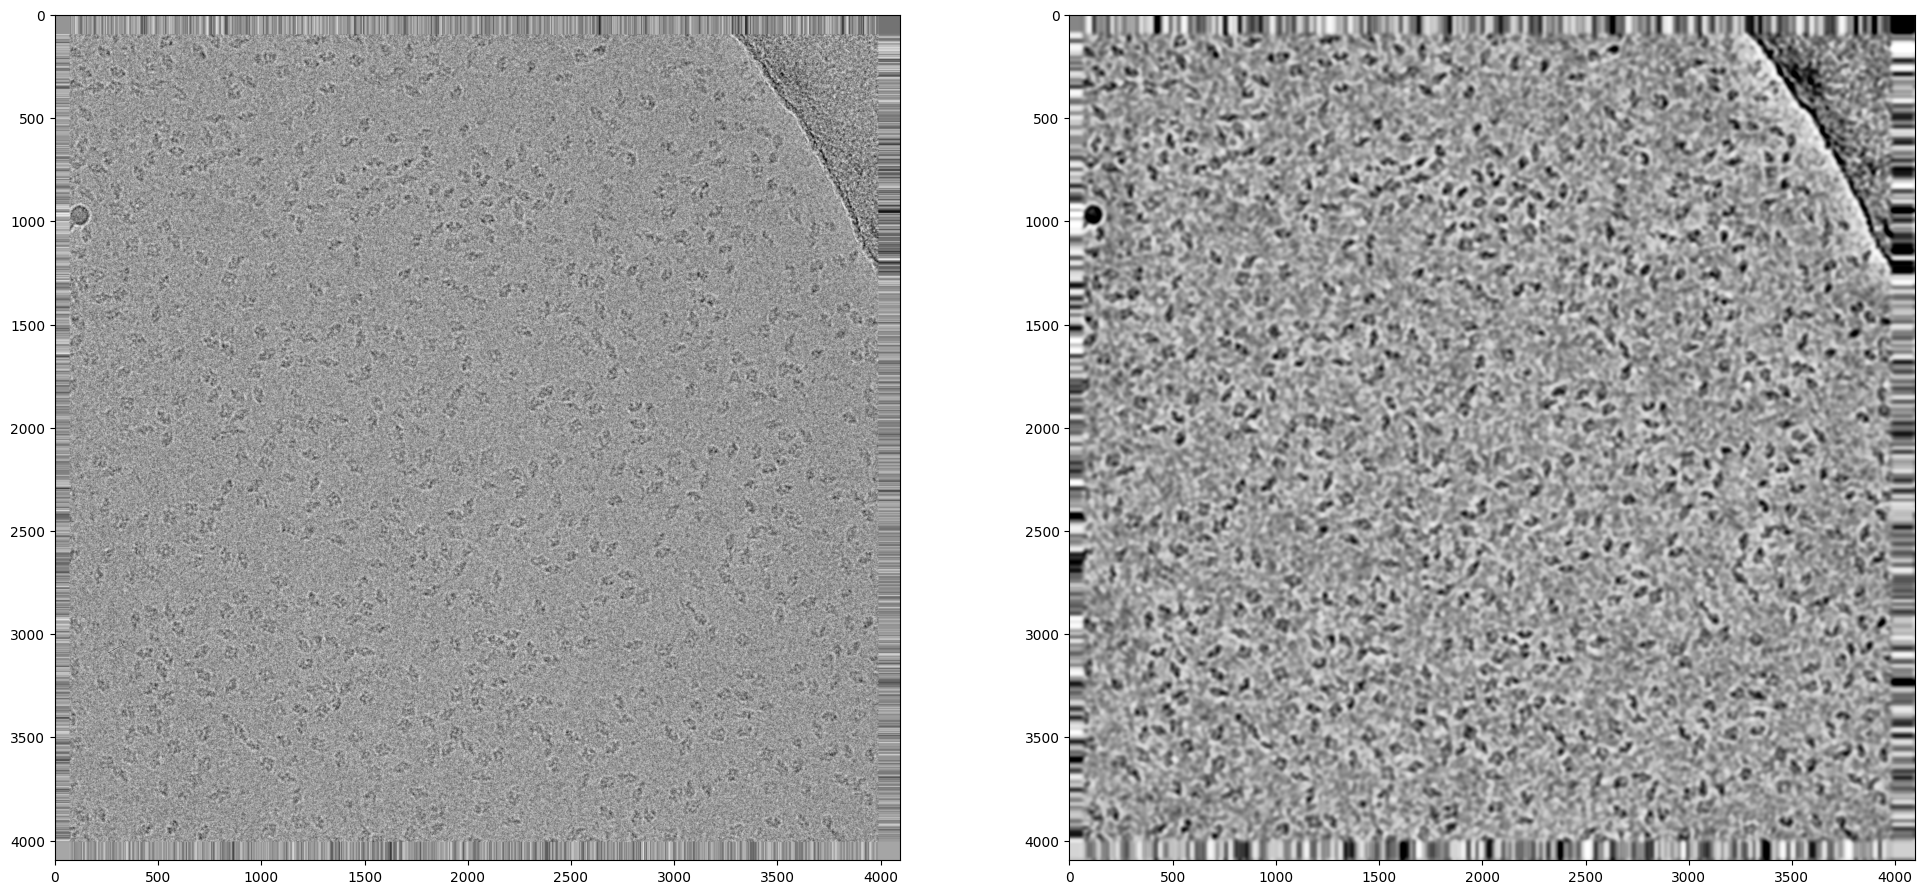

In [ ]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

name = 'Falcon_2012_06_12-14_33_35_0' # @param {type: "string"}

# Load the raw micrograph, ensuring it's a NumPy array.
mic_raw = load_image(os.path.join(DATA_DIR_PATH, f"{name}.mrc"), standardize=True)[0]


# Load the denoised micrograph, ensuring it's a NumPy array.
mic_dn = load_image(os.path.join(OUTPUT_DIR_PATH, f"{name}.mrc"), standardize=True)[0]


# Plotting the images
_, ax = plt.subplots(1, 2, figsize=(24, 12))

ax[0].imshow(mic_raw, vmin=-4, vmax=4, cmap='Greys_r')
ax[1].imshow(mic_dn, vmin=-4, vmax=4, cmap='Greys_r')

plt.show()